In [1]:
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter

from pymargins import Margins

rng = np.random.default_rng(0)
n = 2000
df = pd.DataFrame({
    "age": rng.normal(60, 10, n),
    "treated": rng.binomial(1, 0.5, n),
    "biomarker": rng.normal(0, 1, n),
})
lp = 0.05 * (df["age"] - 60) - 0.6 * df["treated"] + 0.3 * df["biomarker"]
df["duration"] = rng.exponential(np.exp(-lp) * 10)
df["event"] = (df["duration"] < 12).astype(int)
df["duration"] = df["duration"].clip(upper=12)

cph = CoxPHFitter().fit(df, duration_col="duration", event_col="event")

In [2]:
from pymargins.adapters import LifelinesCoxPHAdapter

_adapter = LifelinesCoxPHAdapter(cph, training_data=df)
m = Margins.log_scale(cph, adapter=_adapter, at="overall")
print(m.contrasts(
    scenarios=[
        {"atexog": {"treated": 1}, "label": "treated"},
        {"atexog": {"treated": 0}, "label": "control"},
    ],
    contrasts=[+1, -1],
).summary())

             Margins Result (delta, level=0.95)             
         estimate  std err        z  P>|z|  [95% Conf. Int.]
------------------------------------------------------------
treated    0.5820   0.0581  -9.3201  0.000    0.5194, 0.6522

n = 2000
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
κ: 0.000
Delta-vs-sim disagreement: 0.794%


In [3]:
print(Margins.log_scale(cph, adapter=_adapter, at="overall").dydx("biomarker").summary())

               Margins Result (delta, level=0.95)              
           estimate  std err         z  P>|z|  [95% Conf. Int.]
---------------------------------------------------------------
biomarker    0.4009   0.0909  -10.0577  0.000    0.3355, 0.4791

n = 2000
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
κ: 0.082
Delta-vs-sim disagreement: 2.484%


In [4]:
from pymargins.adapters import LifelinesCoxPHSurvivalAdapter

m_surv = Margins(
    cph,
    adapter=LifelinesCoxPHSurvivalAdapter(cph, training_data=df, prediction_time=365),
    at="overall",
    method="bootstrap",
    n_boot=100,
)

# RMST at 3 years (1095 days) under treated and control
rmst_treat   = m_surv.rmst(horizon=1095, atexog={"treated": 1}, n_grid=40)
rmst_control = m_surv.rmst(horizon=1095, atexog={"treated": 0}, n_grid=40)

print(rmst_treat.summary())
print(rmst_control.summary())

# Difference with joint inference
rmst_diff = rmst_treat - rmst_control
print(rmst_diff.summary())

              Margins Result (bootstrap, level=0.95)              
           estimate  std err  statistic  P>|z|    [95% Conf. Int.]
------------------------------------------------------------------
treated=1  523.1283  16.9437   523.1283  0.000  494.4692, 557.3768

n = 2000
              Margins Result (bootstrap, level=0.95)              
           estimate  std err  statistic  P>|z|    [95% Conf. Int.]
------------------------------------------------------------------
treated=0  341.9277  13.8196   341.9277  0.000  313.2777, 364.5015

n = 2000
                      Margins Result (bootstrap, level=0.95)                      
                           estimate  std err  statistic  P>|z|    [95% Conf. Int.]
----------------------------------------------------------------------------------
(treated=1) - (treated=0)  181.2006  18.6655   181.2006  0.000  155.1680, 220.7777

n = 2000


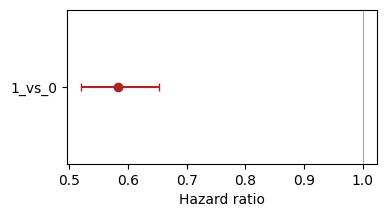

In [5]:
import matplotlib.pyplot as plt
from pymargins import reference

scen, W = reference("treated", [0, 1], ref_level=0)
res = m.contrasts(scenarios=scen, contrasts=W)
df_forest = res.to_frame()

fig, ax = plt.subplots(figsize=(4, 2))
y = range(len(df_forest))
ax.errorbar(
    df_forest["estimate"], y,
    xerr=[df_forest["estimate"] - df_forest["ci_lower"],
          df_forest["ci_upper"] - df_forest["estimate"]],
    fmt="o", capsize=3, color="firebrick"
)
ax.axvline(1, color="grey", lw=0.5)
ax.set_yticks(list(y))
ax.set_yticklabels(df_forest["label"])
ax.set_xlabel("Hazard ratio")
ax.invert_yaxis()